# MCal Training Dynamics: Sample Size Study

Train MCal_CE_Uncond with different sample sizes on binomial-ablated data (p=0.5).

**Approach**: For each dataset, load clean samples and create ablated versions with p=0.5 masking. Train MCal to predict clean logits from ablated logits.

**Datasets**: MRI (vision), MedQA (language), PhysioNet (tabular)

**Sample sizes**: [50, 100, 250, 500, 1000, 2000]

In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
import json

# Setup paths
current_dir = Path('.').absolute()
mcal_root = current_dir.parent if current_dir.name == 'experiments' else current_dir
sys.path.insert(0, str(mcal_root))
sys.path.insert(0, str(mcal_root / 'src'))
sys.path.insert(0, str(mcal_root / 'experiments'))

from src.calibrators.mcal_ce import MCal_CE

device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
print(f"MCal root: {mcal_root}")
print(f"Device: {device}")

MCal root: /ssd1/ayx98/MCal
Device: cuda:3


## Helper Functions

In [2]:
def generate_mri_data(split='test', n_samples=2000):
    """Load clean MRI images and ablated versions, generate predictions."""
    print(f"Generating MRI data (split={split}, n={n_samples})...")
    import timm
    from all_data_loaders import load_mri_clean_and_ablated
    
    # Load clean and ablated images (perfectly aligned), shuffled for balanced sampling
    images_clean, images_ablated, labels = load_mri_clean_and_ablated(
        split=split, p_ablate=0.5, n_samples=n_samples, seed=42, shuffle=True
    )
    
    # Load model and generate predictions
    model_path = mcal_root / 'saved_models' / 'mri' / 'vit_mri_ps32_ablate0.50_best.pth'
    checkpoint = torch.load(model_path, map_location=device)
    num_classes = checkpoint['model_state_dict']['head.weight'].shape[0]
    
    model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=num_classes)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device).eval()
    
    with torch.no_grad():
        probs_clean = F.softmax(model(images_clean.to(device)), dim=1).cpu().numpy()
        probs_ablated = F.softmax(model(images_ablated.to(device)), dim=1).cpu().numpy()
    
    print(f"  Clean: {probs_clean.shape}, Ablated: {probs_ablated.shape}")
    return probs_clean, probs_ablated, labels.numpy()


def generate_medqa_data(split='test', n_samples=2000):
    """Load clean MedQA and ablated versions, generate predictions."""
    print(f"Generating MedQA data (split={split}, n={n_samples})...")
    from all_data_loaders import load_medqa_clean_and_ablated
    from transformers import AutoTokenizer, AutoModelForCausalLM
    
    # Load clean and ablated datasets (perfectly aligned), shuffled for balanced sampling
    dataset_clean, dataset_ablated = load_medqa_clean_and_ablated(
        split=split, p_ablate=0.5, n_samples=n_samples, seed=42, shuffle=True
    )
    
    # Load model
    model_path = mcal_root / 'saved_models' / 'language' / 'Meta-Llama-3-8B-Instruct'
    print(f"  Loading LLaMA...")
    tokenizer = AutoTokenizer.from_pretrained(str(model_path))
    model = AutoModelForCausalLM.from_pretrained(str(model_path), torch_dtype=torch.float16, device_map=device)
    model.eval()
    
    answer_tokens = [tokenizer.encode(l, add_special_tokens=False)[0] for l in ['A', 'B', 'C', 'D', 'E']]
    probs_clean, probs_ablated, labels = [], [], []
    
    for item_clean, item_ablated in tqdm(zip(dataset_clean, dataset_ablated), total=len(dataset_clean)):
        options_text = "\n".join([f"{opt['key']}. {opt['value']}" for opt in item_clean['options']])
        
        # Clean predictions
        prompt = f"Question: {item_clean['question']}\n\nOptions:\n{options_text}\nAnswer: "
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            logits = model(**inputs).logits[0, -1, answer_tokens]
        probs_clean.append(F.softmax(logits, dim=0).cpu().numpy())
        
        # Ablated predictions
        prompt = f"Question: {item_ablated['question']}\n\nOptions:\n{options_text}\nAnswer: "
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            logits = model(**inputs).logits[0, -1, answer_tokens]
        probs_ablated.append(F.softmax(logits, dim=0).cpu().numpy())
        
        labels.append(ord(item_clean['answer_idx']) - ord('A'))
    
    probs_clean = np.array(probs_clean)
    probs_ablated = np.array(probs_ablated)
    labels = np.array(labels)
    print(f"  Clean: {probs_clean.shape}, Ablated: {probs_ablated.shape}")
    return probs_clean, probs_ablated, labels


# Global XGBoost model for PhysioNet (train once, use for all splits)
_physionet_model = None
_physionet_imputer = None

def generate_physionet_data(split='test', n_samples=1000):
    """Load clean PhysioNet and ablated versions, generate predictions."""
    global _physionet_model, _physionet_imputer
    
    print(f"Generating PhysioNet data (split={split}, n={n_samples})...")
    from all_data_loaders import load_physionet_clean_and_ablated
    from sklearn.impute import SimpleImputer
    import xgboost as xgb
    
    # Train model once on training data
    if _physionet_model is None:
        print("  Training XGBoost on training data...")
        from all_data_loaders import load_physionet_clean
        X_train_full, y_train_full = load_physionet_clean(split='train', n_samples=None)
        
        _physionet_imputer = SimpleImputer(strategy='mean')
        X_imputed = _physionet_imputer.fit_transform(X_train_full)
        
        _physionet_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                                            eta=0.1, max_depth=6, seed=42, tree_method='hist')
        _physionet_model.fit(X_imputed, y_train_full)
        print(f"  Trained on {len(X_train_full)} samples")
    
    # Load clean and ablated data for the requested split, shuffled for balanced sampling
    X_clean, X_ablated, y = load_physionet_clean_and_ablated(
        split=split, p_ablate=0.5, n_samples=n_samples, seed=42, shuffle=True
    )
    
    # Generate predictions using the single trained model
    probs_clean = _physionet_model.predict_proba(X_clean)
    probs_ablated = _physionet_model.predict_proba(X_ablated)
    
    print(f"  Clean: {probs_clean.shape}, Ablated: {probs_ablated.shape}")
    return probs_clean, probs_ablated, y

In [3]:
import time

def train_and_eval_mcal(probs_clean_train, probs_ablated_train,
                         probs_clean_test, probs_ablated_test,
                         n_samples, max_steps=5000):
    """Train MCal on n training samples, evaluate on test set."""
    # Subsample training data
    probs_clean_sub = torch.tensor(probs_clean_train[:n_samples], dtype=torch.float32, device=device)
    probs_ablated_sub = torch.tensor(probs_ablated_train[:n_samples], dtype=torch.float32, device=device)
    
    # Target labels from clean predictions
    target_labels = probs_clean_sub.argmax(dim=-1)
    
    # Train calibrator
    calibrator = MCal_CE(num_classes=probs_clean_train.shape[1], head_type="linear")
    calibrator.to(device)
    
    # Time the training
    start_time = time.time()
    stats = calibrator.fit(
        ablated_probs=probs_ablated_sub,
        target_labels=target_labels,
        max_steps=max_steps,
        lr=1e-3,
        verbose=False
    )
    training_time = time.time() - start_time
    
    # Evaluate on test set
    probs_clean_test_t = torch.tensor(probs_clean_test, dtype=torch.float32, device=device)
    probs_ablated_test_t = torch.tensor(probs_ablated_test, dtype=torch.float32, device=device)
    
    with torch.no_grad():
        calibrated_test = calibrator(probs_ablated_test_t)
        test_preds = calibrated_test.argmax(dim=-1)
        test_targets = probs_clean_test_t.argmax(dim=-1)
        test_acc = (test_preds == test_targets).float().mean().item()
    
    stats['test_acc'] = test_acc
    stats['training_time'] = training_time
    return stats

## Run Experiments

In [4]:
sample_sizes = [5, 10, 25, 50, 100, 250, 500, 1000, 2000]
max_steps = 5000

results = {}

In [5]:
# MRI
print("=" * 60)
print("MRI EXPERIMENT")
print("=" * 60)

# Load ALL available train and test data (don't cap training data)
probs_clean_train, probs_ablated_train, labels_train = generate_mri_data(split='train', n_samples=None)
probs_clean_test, probs_ablated_test, labels_test = generate_mri_data(split='test', n_samples=None)

print(f"Train set: {len(probs_clean_train)} samples")
print(f"Test set: {len(probs_clean_test)} samples")

results['mri'] = {}

for n in sample_sizes:
    if n > len(probs_clean_train):
        print(f"\nSkipping n={n} (exceeds training data size)")
        continue
    print(f"\nTraining n={n}...")
    stats = train_and_eval_mcal(probs_clean_train, probs_ablated_train,
                                 probs_clean_test, probs_ablated_test,
                                 n, max_steps)
    results['mri'][n] = stats
    print(f"  Train loss: {stats['loss'][-1]:.6f}, Train acc: {stats['acc'][-1]:.4f}, Test acc: {stats['test_acc']:.4f}")

print("\n✅ MRI complete")

MRI EXPERIMENT
Generating MRI data (split=train, n=None)...
  Clean: (5284, 4), Ablated: (5284, 4)
Generating MRI data (split=test, n=None)...
  Clean: (1311, 4), Ablated: (1311, 4)
Train set: 5284 samples
Test set: 1311 samples

Training n=5...
Initial accuracy: 0.2000
Final accuracy: 1.0000
Target labels distribution: tensor([1, 0, 3, 1], device='cuda:3')
Predictions distribution: tensor([1, 0, 3, 1], device='cuda:3')
Original predictions (before calibration): tensor([1, 0, 3, 1], device='cuda:3')
Sample target labels (first 10): tensor([2, 2, 3, 0, 2], device='cuda:3')
Sample predictions (first 10): tensor([2, 2, 3, 0, 2], device='cuda:3')
Sample original preds (first 10): tensor([2, 2, 3, 0, 2], device='cuda:3')
Results saved to: results/mcal_ce_results_linear_4classes.json
Final calibrated probabilities shape: torch.Size([5, 4])
Mean ablated probabilities: tensor([0.2001, 0.0041, 0.5975, 0.1983], device='cuda:3')
Mean argmaxed ablated probabilities: tensor([0.2000, 0.0000, 0.6000,

In [6]:
# MedQA
print("=" * 60)
print("MEDQA EXPERIMENT")
print("=" * 60)

# Load train and test data
probs_clean_train, probs_ablated_train, labels_train = generate_medqa_data(split='train', n_samples=2000)
probs_clean_test, probs_ablated_test, labels_test = generate_medqa_data(split='test', n_samples=None)

results['medqa'] = {}

for n in sample_sizes:
    if n > len(probs_clean_train):
        continue
    print(f"\nTraining n={n}...")
    stats = train_and_eval_mcal(probs_clean_train, probs_ablated_train,
                                 probs_clean_test, probs_ablated_test,
                                 n, max_steps)
    results['medqa'][n] = stats
    print(f"  Train loss: {stats['loss'][-1]:.6f}, Train acc: {stats['acc'][-1]:.4f}, Test acc: {stats['test_acc']:.4f}")

print("\n✅ MedQA complete")

MEDQA EXPERIMENT
Generating MedQA data (split=train, n=2000)...
  Loading LLaMA...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [01:13<00:00, 27.05it/s]


  Clean: (2000, 5), Ablated: (2000, 5)
Generating MedQA data (split=test, n=None)...
  Loading LLaMA...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 1272/1272 [00:47<00:00, 27.05it/s]


  Clean: (1272, 5), Ablated: (1272, 5)

Training n=5...
Initial accuracy: 0.4000
Final accuracy: 1.0000
Target labels distribution: tensor([1, 1, 0, 2, 1], device='cuda:3')
Predictions distribution: tensor([1, 1, 0, 2, 1], device='cuda:3')
Original predictions (before calibration): tensor([1, 0, 1, 2, 1], device='cuda:3')
Sample target labels (first 10): tensor([0, 4, 1, 3, 3], device='cuda:3')
Sample predictions (first 10): tensor([0, 4, 1, 3, 3], device='cuda:3')
Sample original preds (first 10): tensor([0, 4, 2, 3, 3], device='cuda:3')
Results saved to: results/mcal_ce_results_linear_5classes.json
Final calibrated probabilities shape: torch.Size([5, 5])
Mean ablated probabilities: tensor([0.1909, 0.0341, 0.1526, 0.4033, 0.2192], device='cuda:3')
Mean argmaxed ablated probabilities: tensor([0.2000, 0.0000, 0.2000, 0.4000, 0.2000], device='cuda:3')
Mean calibrated probabilities: tensor([1.9975e-01, 1.9995e-01, 1.1440e-06, 4.0020e-01, 2.0009e-01],
       device='cuda:3')
Mean argmax pr

In [7]:
# PhysioNet
print("=" * 60)
print("PHYSIONET EXPERIMENT")
print("=" * 60)

# Load train and test data
probs_clean_train, probs_ablated_train, labels_train = generate_physionet_data(split='train', n_samples=2000)
probs_clean_test, probs_ablated_test, labels_test = generate_physionet_data(split='test', n_samples=None)

results['physionet'] = {}

for n in [s for s in sample_sizes if s <= 1000]:
    if n > len(probs_clean_train):
        continue
    print(f"\nTraining n={n}...")
    stats = train_and_eval_mcal(probs_clean_train, probs_ablated_train,
                                 probs_clean_test, probs_ablated_test,
                                 n, max_steps)
    results['physionet'][n] = stats
    print(f"  Train loss: {stats['loss'][-1]:.6f}, Train acc: {stats['acc'][-1]:.4f}, Test acc: {stats['test_acc']:.4f}")

print("\n✅ PhysioNet complete")

PHYSIONET EXPERIMENT
Generating PhysioNet data (split=train, n=2000)...
  Training XGBoost on training data...
  Trained on 840 samples
  Clean: (840, 2), Ablated: (840, 2)
Generating PhysioNet data (split=test, n=None)...
  Clean: (210, 2), Ablated: (210, 2)

Training n=5...
Initial accuracy: 0.2000
Final accuracy: 1.0000
Target labels distribution: tensor([1, 4], device='cuda:3')
Predictions distribution: tensor([1, 4], device='cuda:3')
Original predictions (before calibration): tensor([3, 2], device='cuda:3')
Sample target labels (first 10): tensor([1, 1, 1, 1, 0], device='cuda:3')
Sample predictions (first 10): tensor([1, 1, 1, 1, 0], device='cuda:3')
Sample original preds (first 10): tensor([1, 1, 0, 0, 0], device='cuda:3')
Results saved to: results/mcal_ce_results_linear_2classes.json
Final calibrated probabilities shape: torch.Size([5, 2])
Mean ablated probabilities: tensor([0.5508, 0.4492], device='cuda:3')
Mean argmaxed ablated probabilities: tensor([0.6000, 0.4000], device='c

## Visualization

In [8]:
def plot_training_curves(results_dict, dataset_name, metric='loss'):
    fig, ax = plt.subplots(figsize=(4, 3))
    
    for n in sorted(results_dict.keys()):
        stats = results_dict[n]
        ax.plot(stats[metric], label=f'n={n}', alpha=0.8)
    
    ax.set_xlabel('Training Steps', fontsize=11)
    ax.set_ylabel('Loss' if metric == 'loss' else 'Accuracy', fontsize=11)
    ax.legend(fontsize=8, loc='best', title=dataset_name, title_fontsize=9)
    ax.tick_params(labelsize=10)
    ax.grid(alpha=0.3)
    if metric == 'loss':
        ax.set_yscale('log')
    
    plt.tight_layout()
    return fig

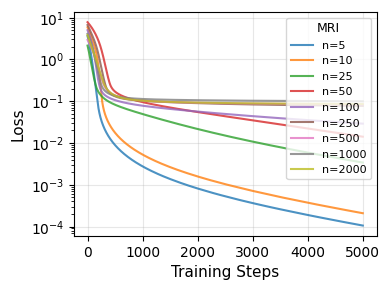

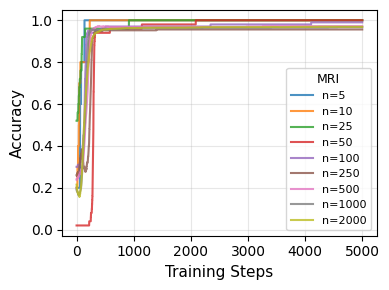

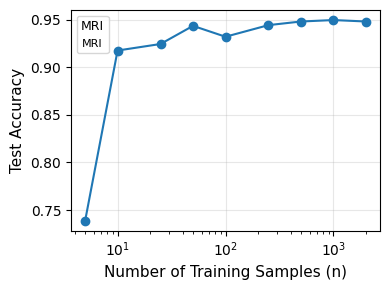

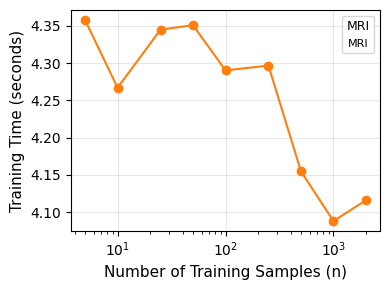

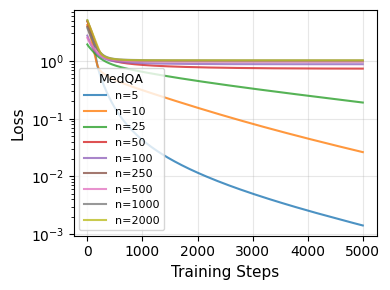

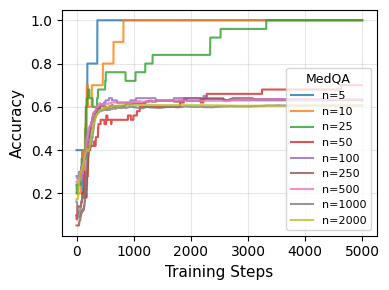

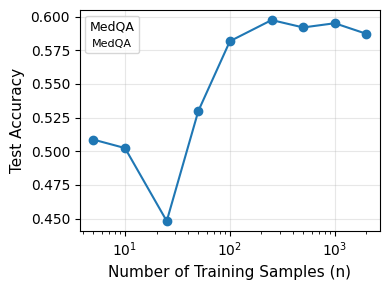

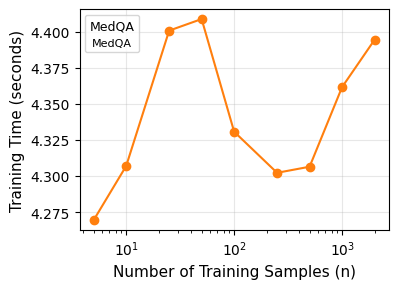

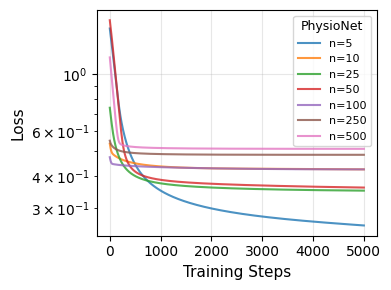

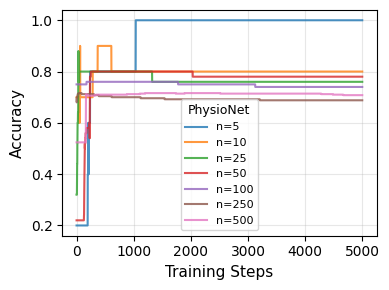

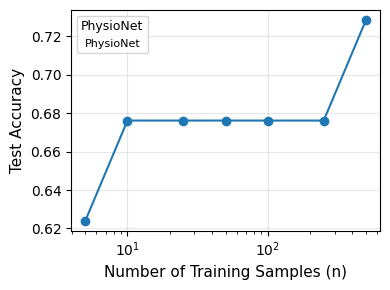

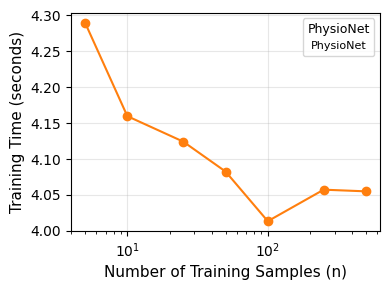

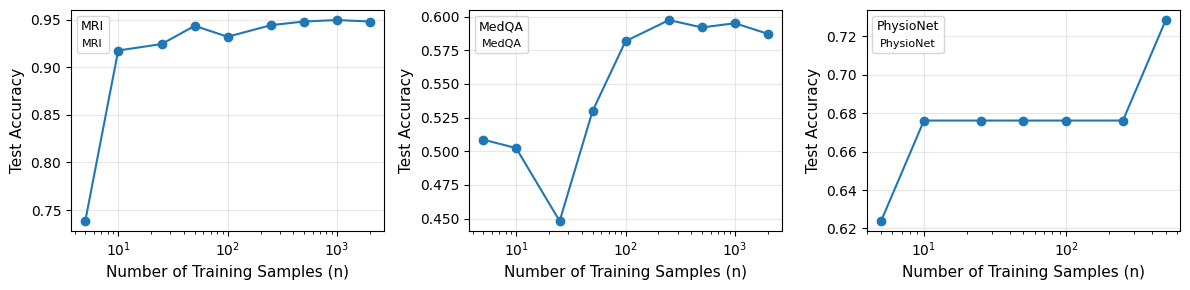

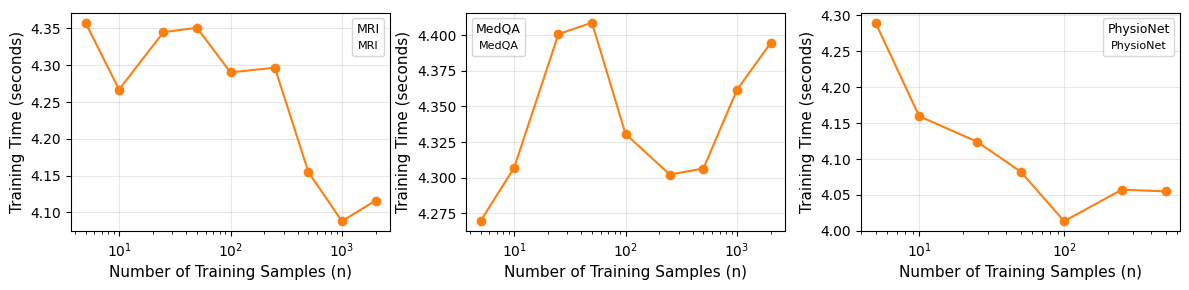


✅ All plots saved to /ssd1/ayx98/MCal/experiments/results/


In [9]:
# Plot all training curves
output_dir = mcal_root / 'experiments' / 'results'
output_dir.mkdir(exist_ok=True, parents=True)

# Map dataset names for display
dataset_display_names = {
    'mri': 'MRI',
    'medqa': 'MedQA',
    'physionet': 'PhysioNet'
}

for dataset_name, dataset_results in results.items():
    display_name = dataset_display_names.get(dataset_name, dataset_name.upper())
    
    # Loss curves (training dynamics over steps)
    fig = plot_training_curves(dataset_results, display_name, metric='loss')
    plt.savefig(output_dir / f'{dataset_name}_loss_curves.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    # Accuracy curves (training dynamics over steps)
    fig = plot_training_curves(dataset_results, display_name, metric='acc')
    plt.savefig(output_dir / f'{dataset_name}_acc_curves.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    # Test accuracy vs sample size (individual plot per dataset)
    sample_sizes_list = sorted(dataset_results.keys())
    test_accs = [dataset_results[n]['test_acc'] for n in sample_sizes_list]

    fig, ax = plt.subplots(figsize=(4, 3))
    ax.plot(sample_sizes_list, test_accs, 'o-', linewidth=1.5, markersize=6)
    ax.set_xlabel('Number of Training Samples (n)', fontsize=11)
    ax.set_ylabel('Test Accuracy', fontsize=11)
    # Create a dummy legend entry just for the title
    ax.plot([], [], ' ', label=display_name)
    ax.legend(fontsize=8, loc='best', title=display_name, title_fontsize=9, handlelength=0, handletextpad=0)
    ax.tick_params(labelsize=10)
    ax.grid(alpha=0.3)
    ax.set_xscale('log')
    plt.tight_layout()
    plt.savefig(output_dir / f'{dataset_name}_test_acc_vs_n.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Training time vs sample size (individual plot per dataset)
    training_times = [dataset_results[n]['training_time'] for n in sample_sizes_list]
    
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.plot(sample_sizes_list, training_times, 'o-', linewidth=1.5, markersize=6, color='C1')
    ax.set_xlabel('Number of Training Samples (n)', fontsize=11)
    ax.set_ylabel('Training Time (seconds)', fontsize=11)
    # Create a dummy legend entry just for the title
    ax.plot([], [], ' ', label=display_name)
    ax.legend(fontsize=8, loc='best', title=display_name, title_fontsize=9, handlelength=0, handletextpad=0)
    ax.tick_params(labelsize=10)
    ax.grid(alpha=0.3)
    ax.set_xscale('log')
    plt.tight_layout()
    plt.savefig(output_dir / f'{dataset_name}_training_time_vs_n.pdf', dpi=300, bbox_inches='tight')
    plt.show()

# Plot test accuracy vs sample size (combined plot)
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for idx, (dataset_name, dataset_results) in enumerate(results.items()):
    ax = axes[idx]
    display_name = dataset_display_names.get(dataset_name, dataset_name.upper())

    # Extract sample sizes and test accuracies
    sample_sizes_list = sorted(dataset_results.keys())
    test_accs = [dataset_results[n]['test_acc'] for n in sample_sizes_list]

    # Plot
    ax.plot(sample_sizes_list, test_accs, 'o-', linewidth=1.5, markersize=6)
    ax.set_xlabel('Number of Training Samples (n)', fontsize=11)
    ax.set_ylabel('Test Accuracy', fontsize=11)
    # Create a dummy legend entry just for the title
    ax.plot([], [], ' ', label=display_name)
    ax.legend(fontsize=8, loc='best', title=display_name, title_fontsize=9, handlelength=0, handletextpad=0)
    ax.tick_params(labelsize=10)
    ax.grid(alpha=0.3)
    ax.set_xscale('log')

plt.tight_layout()
plt.savefig(output_dir / 'test_accuracy_vs_sample_size_combined.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot training time vs sample size (combined plot)
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for idx, (dataset_name, dataset_results) in enumerate(results.items()):
    ax = axes[idx]
    display_name = dataset_display_names.get(dataset_name, dataset_name.upper())

    # Extract sample sizes and training times
    sample_sizes_list = sorted(dataset_results.keys())
    training_times = [dataset_results[n]['training_time'] for n in sample_sizes_list]

    # Plot
    ax.plot(sample_sizes_list, training_times, 'o-', linewidth=1.5, markersize=6, color='C1')
    ax.set_xlabel('Number of Training Samples (n)', fontsize=11)
    ax.set_ylabel('Training Time (seconds)', fontsize=11)
    # Create a dummy legend entry just for the title
    ax.plot([], [], ' ', label=display_name)
    ax.legend(fontsize=8, loc='best', title=display_name, title_fontsize=9, handlelength=0, handletextpad=0)
    ax.tick_params(labelsize=10)
    ax.grid(alpha=0.3)
    ax.set_xscale('log')

plt.tight_layout()
plt.savefig(output_dir / 'training_time_vs_sample_size_combined.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ All plots saved to {output_dir}/")

In [10]:
# Save results
results_file = mcal_root / 'results' / 'mcal_training_dynamics.json'
with open(results_file, 'w') as f:
    json.dump(results, f, indent=2)
print(f"Results saved to: {results_file}")

Results saved to: /ssd1/ayx98/MCal/results/mcal_training_dynamics.json
